# Churn Prediction

In [1]:
import pandas as pd

# Load the datasets
customers_df = pd.read_csv('../data/customers.csv')
orders_df = pd.read_csv('../data/orders_with_churn_and_payment.csv')
products_df = pd.read_csv('../data/products_updated.csv')
sales_df = pd.read_csv('../data/sales_updated.csv')
rfm_df = pd.read_csv('../data/customer_segment_data_rfm_df.csv')
kmeans_df = pd.read_csv('../data/customer_segment_data_kMeans.csv')

# Explore each DataFrame
print("Customers DataFrame:")
display(customers_df.head())
customers_df.info()
display(customers_df.describe())

print("\nOrders DataFrame:")
display(orders_df.head())
orders_df.info()
display(orders_df.describe())

print("\nProducts DataFrame:")
display(products_df.head())
products_df.info()
display(products_df.describe())

print("\nSales DataFrame:")
display(sales_df.head())
sales_df.info()
display(sales_df.describe())

print("\nRFM DataFrame:")
display(rfm_df.head())
rfm_df.info()
display(rfm_df.describe())

print("\nKMeans DataFrame:")
display(kmeans_df.head())
kmeans_df.info()
display(kmeans_df.describe())

Customers DataFrame:


,customer_id,customer_name,gender,age,home_address,zip_code,city,state,country
0,1,Leanna Busson,Female,30,8606 Victoria TerraceSuite 560,5464,Johnstonhaven,Northern Territory,Australia
1,2,Zabrina Harrowsmith,Genderfluid,69,8327 Kirlin SummitApt. 461,8223,New Zacharyfort,South Australia,Australia
2,3,Shina Dullaghan,Polygender,59,269 Gemma SummitSuite 109,5661,Aliburgh,Australian Capital Territory,Australia
3,4,Hewet McVitie,Bigender,67,743 Bailey GroveSuite 141,1729,South Justinhaven,Queensland,Australia
4,5,Rubia Ashleigh,Polygender,30,48 Hyatt ManorSuite 375,4032,Griffithsshire,Queensland,Australia


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    1000 non-null   int64 
 1   customer_name  1000 non-null   object
 2   gender         1000 non-null   object
 3   age            1000 non-null   int64 
 4   home_address   1000 non-null   object
 5   zip_code       1000 non-null   int64 
 6   city           1000 non-null   object
 7   state          1000 non-null   object
 8   country        1000 non-null   object
dtypes: int64(3), object(6)
memory usage: 70.4+ KB


,customer_id,age,zip_code
count,1000.000000,1000.000000,1000.000000
mean,500.500000,49.860000,5004.872000
std,288.819436,17.647828,2884.497332
min,1.000000,20.000000,2.000000
25%,250.750000,34.000000,2401.750000
50%,500.500000,50.000000,5083.000000
75%,750.250000,65.000000,7460.250000
max,1000.000000,80.000000,9998.000000



Orders DataFrame:


...

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Segment
count,616.00000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000
mean,501.75974,122.439935,1.621753,1675.000000,2.826299,1.193182,1.353896,295.915584
std,286.16075,84.286077,0.856224,1069.724092,1.085315,0.503664,0.571477,110.083587
min,1.00000,0.000000,1.000000,100.000000,1.000000,1.000000,1.000000,111.000000
25%,259.50000,50.750000,1.000000,878.250000,2.000000,1.000000,1.000000,211.000000
50%,496.50000,110.500000,1.000000,1439.000000,3.000000,1.000000,1.000000,311.000000
75%,751.00000,191.000000,2.000000,2165.000000,4.000000,1.000000,2.000000,411.000000
max,1000.00000,296.000000,6.000000,7632.000000,4.000000,4.000000,4.000000,444.000000



KMeans DataFrame:


,customer_id,payment,age,state,cluster
0,1,1641.0,30,Northern Territory,2
1,7,1017.0,76,Queensland,1
2,10,270.0,70,Western Australia,1
3,11,382.0,39,Northern Territory,1
4,12,1551.0,78,South Australia,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  617 non-null    int64  
 1   payment      617 non-null    float64
 2   age          617 non-null    int64  
 3   state        617 non-null    object 
 4   cluster      617 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 24.2+ KB


,customer_id,payment,age,cluster
count,617.000000,617.000000,617.000000,617.000000
mean,501.604538,1672.285251,49.358185,1.247974
std,285.954370,1070.980481,17.435123,0.721943
min,1.000000,0.000000,20.000000,0.000000
25%,260.000000,876.000000,34.000000,1.000000
50%,496.000000,1437.000000,49.000000,1.000000
75%,750.000000,2165.000000,63.000000,2.000000
max,1000.000000,7632.000000,80.000000,3.000000


## Kohort analizi - i̇lk sipariş tarihi 

In [2]:
# Data preparation for cohort analysis: Determine each customer's first order date

# Convert the 'order_date' column in the orders_df DataFrame to datetime format.
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

# Find the earliest order date for each customer.
# Group orders_df by 'customer_id' and calculate the minimum value in the 'order_date' column (first order date) for each customer.
first_order_date_df = orders_df.groupby('customer_id')['order_date'].min().reset_index()
# Rename the newly created column to make it more descriptive.
first_order_date_df.rename(columns={'order_date': 'first_order_date'}, inplace=True)

# Check if the data preparation was successful by displaying the first few rows and summary info of the new DataFrame.
print("DataFrame with Customers' First Order Date:")
display(first_order_date_df.head())
first_order_date_df.info()

DataFrame with Customers' First Order Date:


,customer_id,first_order_date
0,1,2021-02-18
1,7,2021-05-21
2,10,2021-03-09
3,11,2021-05-28
4,12,2021-06-19


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       617 non-null    int64         
 1   first_order_date  617 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 9.8 KB


In [3]:
import numpy as np

# Add first order date to orders_df
# Merge orders_df with first_order_date_df on the 'customer_id' column
orders_with_first_order = pd.merge(orders_df, first_order_date_df, on='customer_id', how='left')

# Exclude customers who never placed an order during the observation period (first_order_date is NaN)
# Since first_order_date_df only contains customers who placed orders, there won't be NaNs after a left merge.
# However, keeping this line ensures safety if first_order_date_df is created differently.
orders_with_first_order.dropna(subset=['first_order_date'], inplace=True)

# Calculate cohort (the month the customer was acquired)
# Convert the 'first_order_date' column to monthly periods
orders_with_first_order['first_order_month'] = orders_with_first_order['first_order_date'].dt.to_period('M')

# Calculate the month when the order was placed
# Convert the 'order_date' column to monthly periods
orders_with_first_order['order_month'] = orders_with_first_order['order_date'].dt.to_period('M')

# Calculate the cohort index (number of months since the first order)
# Compute the difference between the order month and the first order month in months
orders_with_first_order['cohort_index'] = (orders_with_first_order.order_month - orders_with_first_order.first_order_month).apply(lambda x: x.n)

# Display the first few rows and info of the DataFrame with cohort information
print("\nOrders DataFrame with Cohort Information:")
display(orders_with_first_order.head())
orders_with_first_order.info()


Orders DataFrame with Cohort Information:


,order_id,customer_id,order_date,delivery_date,delivery_time,payment,churn,first_order_date,first_order_month,order_month,cohort_index
0,1,64,2021-08-30,2021-09-24,25 days,1487.0,0,2021-08-30,2021-08,2021-08,0
1,2,473,2021-02-03,2021-02-13,10 days,1130.0,1,2021-02-03,2021-02,2021-02,0
2,3,774,2021-10-08,2021-11-03,26 days,508.0,0,2021-03-30,2021-03,2021-10,7
3,4,433,2021-05-06,2021-05-19,13 days,976.0,1,2021-01-31,2021-01,2021-05,4
4,5,441,2021-03-23,2021-03-24,1 days,2043.0,1,2021-03-23,2021-03,2021-03,0


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           1000 non-null   int64         
 1   customer_id        1000 non-null   int64         
 2   order_date         1000 non-null   datetime64[ns]
 3   delivery_date      1000 non-null   object        
 4   delivery_time      1000 non-null   object        
 5   payment            993 non-null    float64       
 6   churn              1000 non-null   int64         
 7   first_order_date   1000 non-null   datetime64[ns]
 8   first_order_month  1000 non-null   period[M]     
 9   order_month        1000 non-null   period[M]     
 10  cohort_index       1000 non-null   int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(2), period[M](2)
memory usage: 93.8+ KB


In [4]:
orders_with_first_order.loc[orders_with_first_order['customer_id'] == 1]

,order_id,customer_id,order_date,delivery_date,delivery_time,payment,churn,first_order_date,first_order_month,order_month,cohort_index
454,455,1,2021-04-04,2021-04-06,2 days,500.0,1,2021-02-18,2021-02,2021-04,2
669,670,1,2021-03-06,2021-04-01,26 days,749.0,1,2021-02-18,2021-02,2021-03,1
728,729,1,2021-02-18,2021-03-01,11 days,392.0,1,2021-02-18,2021-02,2021-02,0


### CREATION AND VISUALIZATION OF CUSTOMER COHORT MATRIX
This matrix is a critical step in cohort analysis to understand customer acquisition across different months and how many of these customers are retained in the following months.

In [5]:
# CREATION AND VISUALIZATION OF CUSTOMER COHORT MATRIX

# Group by first order month and cohort index and count unique customers
# Calculate the number of unique customers by first order month and cohort index
cohort_data = orders_with_first_order.groupby(['first_order_month', 'cohort_index'])['customer_id'].nunique().reset_index()

# Pivot the table to create a cohort matrix
# Pivot the table to form the cohort matrix
cohort_matrix = cohort_data.pivot_table(index='first_order_month', columns='cohort_index', values='customer_id')

# Display the cohort matrix
# Display the cohort matrix
print("\nCohort Matrix (Number of Customers):")
display(cohort_matrix)


Cohort Matrix (Number of Customers):


cohort_index,0,1,2,3,4,5,6,7,8,9
first_order_month,,,,,,,,,,
2021-01,104.0,13.0,11.0,12.0,10.0,10.0,15.0,10.0,6.0,10.0
2021-02,77.0,14.0,9.0,11.0,5.0,10.0,6.0,6.0,8.0,NaN
2021-03,90.0,5.0,5.0,11.0,12.0,12.0,11.0,11.0,NaN,NaN
2021-04,70.0,4.0,9.0,8.0,6.0,5.0,7.0,NaN,NaN,NaN
2021-05,48.0,7.0,1.0,1.0,6.0,3.0,NaN,NaN,NaN,NaN
2021-06,57.0,8.0,1.0,6.0,5.0,NaN,NaN,NaN,NaN,NaN
2021-07,46.0,7.0,4.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN
2021-08,58.0,4.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09,44.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Divide the cohort matrix by the first cohort size (column 0) to get retention rates
cohort_sizes = cohort_matrix.iloc[:,0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

# Display the retention matrix as percentages
print("\nRetention Matrix (Percentage):")
display(retention_matrix.style.format('{:.2%}')
        .background_gradient(cmap='Blues'))


Retention Matrix (Percentage):


cohort_index,0,1,2,3,4,5,6,7,8,9
first_order_month,,,,,,,,,,
2021-01,100.00%,12.50%,10.58%,11.54%,9.62%,9.62%,14.42%,9.62%,5.77%,9.62%
2021-02,100.00%,18.18%,11.69%,14.29%,6.49%,12.99%,7.79%,7.79%,10.39%,nan%
2021-03,100.00%,5.56%,5.56%,12.22%,13.33%,13.33%,12.22%,12.22%,nan%,nan%
2021-04,100.00%,5.71%,12.86%,11.43%,8.57%,7.14%,10.00%,nan%,nan%,nan%
2021-05,100.00%,14.58%,2.08%,2.08%,12.50%,6.25%,nan%,nan%,nan%,nan%
2021-06,100.00%,14.04%,1.75%,10.53%,8.77%,nan%,nan%,nan%,nan%,nan%
2021-07,100.00%,15.22%,8.70%,15.22%,nan%,nan%,nan%,nan%,nan%,nan%
2021-08,100.00%,6.90%,3.45%,nan%,nan%,nan%,nan%,nan%,nan%,nan%
2021-09,100.00%,6.82%,nan%,nan%,nan%,nan%,nan%,nan%,nan%,nan%


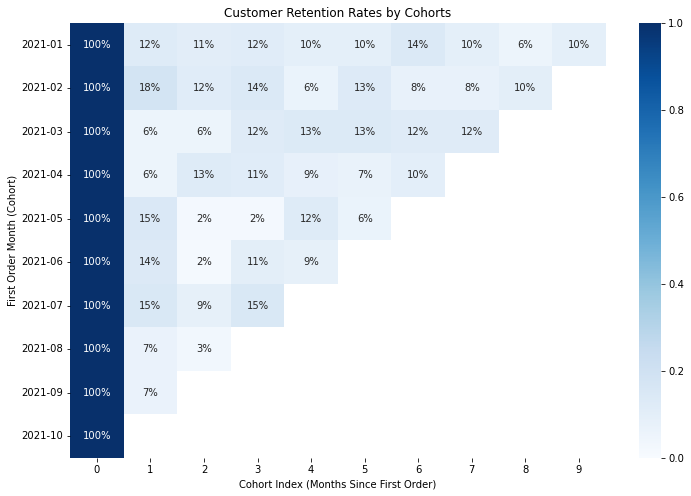

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the retention matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='Blues', vmin=0, vmax=1)
plt.title('Customer Retention Rates by Cohorts')
plt.xlabel('Cohort Index (Months Since First Order)')
plt.ylabel('First Order Month (Cohort)')
plt.yticks(rotation=0) # Rotate y-axis labels for better readability
plt.show()

### Cohort Analysis Results and Findings

The cohort analysis heatmap provides valuable insights by visualizing the retention rates of different customer cohorts (grouped by first order month) over time. Here are the key conclusions and observations that can be drawn from this heatmap:

1. **Rapid Drop in Early Months:** The colors in the heatmap lighten quickly after the first columns (especially as the Cohort Index moves from 0 to 1 and 2). This indicates that a large portion of customers churn within the first few months after their initial order. This early stage of the customer journey is the most critical period for retention strategies.

2. **Stabilization Over Time:** After the initial sharp drop, the colors in the heatmap show less pronounced changes in later cohort indices (moving to the right). This suggests that customers who remain active for a certain period are more likely to be retained in the future, forming a more stable core of the customer base.

3. **Differences Between Cohorts:** Looking at different rows (cohorts with different first order months), some differences in retention rates can be observed. Customers acquired in some months may have been retained slightly better or worse compared to other months. These differences may be related to customer acquisition channels, marketing campaigns, seasonal effects, or external factors during that period. Rows with darker colors in the heatmap generally represent cohorts with better retention performance.

4. **Incomplete Data:** Blank areas or missing values (NaN) in the bottom-right corner of the heatmap indicate that the most recent cohorts (e.g., 2021-10) have not yet fully progressed through the observation period, and therefore retention data for later cohort indices is not available. More time and data are needed to get a complete picture of these cohorts.

5. **Areas of Highest Retention:** The darkest areas in the heatmap show where specific cohorts achieved the highest retention rates at certain cohort indices. These areas can provide clues about successful retention strategies or customer behaviors.

These findings are important for understanding general customer behavior dynamics and, when combined with individual customer-level feature importances from our churn prediction model, can help us plan more informed and targeted actions to prevent customer churn.

### Interpreting Cohort Analysis Results

In [8]:
# Interpretation of Cohort Analysis Results

# The cohort analysis heatmap shows retention rates of different customer cohorts (grouped by first order month) over time. Some key insights that can be drawn from this visualization are:

# 1. Overall Retention Trend: Generally, retention rates drop quickly after the first month for most cohorts. This indicates that many customers do not return after their initial purchases.

# 2. Early Months Are Critical: The first few cohort indices (the first few months after the initial order) experience the most dramatic drops in retention. This highlights that the early stage of the customer journey is critical for retention strategies.

# 3. Differences Between Cohorts: There can be noticeable differences in retention rates across cohorts with different first order months. For example, customers acquired in some months may be more loyal than those in other months. This may reflect the impact of customer acquisition channels, marketing campaigns, or external factors at that time. Darker colors in the heatmap represent higher retention rates.

# 4. Stabilization Over Time: After the initial drops, the retention rates of surviving cohorts tend to stabilize over time. This indicates that customers who remain active for a period are more likely to stay active in the future.

# 5. Seasonal Effects: Differences in retention rates by first order month (cohort) may be influenced by seasonal effects, holidays, or specific promotions.

# 6. Data Limitations: For the most recent cohorts (e.g., 2021-10), the retention matrix is incomplete due to shorter observation periods. More data is needed to get a complete picture of these cohorts.

# Relation to Churn Prediction:

# * Low retention rates in cohort analysis explain why time-related features like Recency (time since last order) are important in our churn prediction model. When a customer does not return, their Recency increases, which in turn raises the churn likelihood.
# * Retention trends across different cohorts can indicate that certain cohorts have higher churn risk. This information, combined with feature importances from the churn prediction model (e.g., effects of specific RFM segments or geographic regions on churn), provides a more comprehensive understanding of churn drivers.
# * In the future, including cohort information (e.g., customer’s cohort or cohort index) as an additional feature in the churn prediction model could potentially improve its performance.

# This analysis provides important insights into overall customer behavior and retention dynamics over time. When used alongside our churn prediction model, it can help us design more targeted and effective strategies to prevent customer attrition.

# Next, we can move to the next step in our plan: Data Preparation for Modeling. In this step, we will prepare the previously merged dataset for machine learning modeling.

## Feature Engineering and Data Merging

In [9]:
# 1. Group orders_df by 'customer_id' to calculate total orders ('total_orders') and total payment ('total_payment') for each customer. Save the result in a new DataFrame called 'customer_order_summary'.
customer_order_summary = orders_df.groupby('customer_id').agg(
    total_orders=('order_id', 'count'),
    total_payment=('payment', 'sum')
).reset_index()

# 2. Perform a left merge of 'customers_df' with 'customer_order_summary' using the 'customer_id' column and name the result 'merged_df'.
merged_df = pd.merge(customers_df, customer_order_summary, on='customer_id', how='left')

# 3. Select 'customer_id', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', and 'RFM_Segment' columns from 'rfm_df' and left merge them with 'merged_df' using 'customer_id'.
rfm_cols = ['customer_id', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_Segment']
merged_df = pd.merge(merged_df, rfm_df[rfm_cols], on='customer_id', how='left')

# 4. Select 'customer_id' and 'cluster' columns from 'kmeans_df' and left merge them with 'merged_df' using 'customer_id'.
kmeans_cols = ['customer_id', 'cluster']
merged_df = pd.merge(merged_df, kmeans_df[kmeans_cols], on='customer_id', how='left')

# 5. Group orders_df by 'customer_id' and calculate the maximum value of the 'churn' column for each customer. Save the result in a new DataFrame called 'customer_churn_status'.
customer_churn_status = orders_df.groupby('customer_id')['churn'].max().reset_index()

# 6. Left merge 'customer_churn_status' with 'merged_df' using the 'customer_id' column.
merged_df = pd.merge(merged_df, customer_churn_status, on='customer_id', how='left')

# 7. Fill missing values in numerical columns (total_orders, total_payment, Recency, Frequency, Monetary, R_score, F_score, M_score, cluster) with 0.
numerical_cols_to_fill = ['total_orders', 'total_payment', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'cluster']
for col in numerical_cols_to_fill:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna(0)

# 8. Fill missing values in the 'churn' column with 0.
merged_df['churn'] = merged_df['churn'].fillna(0)

# 9. Fill missing values in the 'RFM_Segment' column with the string 'No Orders'.
merged_df['RFM_Segment'] = merged_df['RFM_Segment'].fillna('No Orders')

# 10. Drop the columns 'customer_name', 'home_address', 'zip_code', and 'country' from the merged_df DataFrame.
merged_df = merged_df.drop(columns=['customer_name', 'home_address', 'zip_code', 'country'])

# 11. Display the first five rows and summary info of the 'merged_df' DataFrame.
display(merged_df.head())
merged_df.info()

,customer_id,gender,age,city,state,total_orders,total_payment,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Segment,cluster,churn
0,1,Female,30,Johnstonhaven,Northern Territory,3.0,1641.0,203.0,3.0,1641.0,2.0,2.0,1.0,221.0,2.0,1.0
1,2,Genderfluid,69,New Zacharyfort,South Australia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Orders,0.0,0.0
2,3,Polygender,59,Aliburgh,Australian Capital Territory,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Orders,0.0,0.0
3,4,Bigender,67,South Justinhaven,Queensland,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Orders,0.0,0.0
4,5,Polygender,30,Griffithsshire,Queensland,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Orders,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    1000 non-null   int64  
 1   gender         1000 non-null   object 
 2   age            1000 non-null   int64  
 3   city           1000 non-null   object 
 4   state          1000 non-null   object 
 5   total_orders   1000 non-null   float64
 6   total_payment  1000 non-null   float64
 7   Recency        1000 non-null   float64
 8   Frequency      1000 non-null   float64
 9   Monetary       1000 non-null   float64
 10  R_score        1000 non-null   float64
 11  F_score        1000 non-null   float64
 12  M_score        1000 non-null   float64
 13  RFM_Segment    1000 non-null   object 
 14  cluster        1000 non-null   float64
 15  churn          1000 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory usage: 132.8+ KB


## Data Preparation for Modeling

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Convert categorical variables to numerical format using one-hot encoding.
categorical_cols = ['gender', 'city', 'state', 'RFM_Segment']
merged_df_encoded = pd.get_dummies(merged_df, columns=categorical_cols, dummy_na=False)  # dummy_na=False avoids creating a column for NaN if any

# 2. Create the feature matrix (X) and target vector (y).
X = merged_df_encoded.drop('churn', axis=1)
y = merged_df_encoded['churn']

# 3. Split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale numerical features using StandardScaler.
# Identify numerical columns, excluding the target and encoded categorical features
numerical_cols = ['age', 'total_orders', 'total_payment', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'cluster']

scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 5. Check if data preparation was successful by displaying the shapes of the training and test sets and the first few rows of X_train.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

display(X_train.head())

X_train shape: (800, 1015)
X_test shape: (200, 1015)
y_train shape: (800,)
y_test shape: (200,)


C:\Users\zeynep\anaconda3\lib\site-packages\pandas\core\frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)
C:\Users\zeynep\anaconda3\lib\site-packages\pandas\core\frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


,customer_id,age,total_orders,total_payment,Recency,Frequency,Monetary,R_score,F_score,M_score,...,RFM_Segment_412.0,RFM_Segment_421.0,RFM_Segment_422.0,RFM_Segment_423.0,RFM_Segment_431.0,RFM_Segment_432.0,RFM_Segment_433.0,RFM_Segment_443.0,RFM_Segment_444.0,RFM_Segment_No Orders
29,30,-0.683286,-0.974506,-0.888287,-0.857779,-0.972719,-0.888287,-1.080357,-1.054563,-1.053178,...,0,0,0,0,0,0,0,0,0,1
535,536,-1.021476,-0.974506,-0.888287,-0.857779,-0.972719,-0.888287,-1.080357,-1.054563,-1.053178,...,0,0,0,0,0,0,0,0,0,1
695,696,-0.683286,0.962400,1.185940,0.810322,0.963040,1.185940,0.165909,0.370522,1.443244,...,0,0,0,0,0,0,0,0,0,0
557,558,-0.683286,1.930853,1.431426,-0.579762,1.930919,1.431426,1.412176,1.795608,1.443244,...,0,0,1,0,0,0,0,0,0,0
836,837,0.162191,-0.974506,-0.888287,-0.857779,-0.972719,-0.888287,-1.080357,-1.054563,-1.053178,...,0,0,0,0,0,0,0,0,0,1


### Model Selection and Training

In [11]:
from sklearn.linear_model import LogisticRegression

# Select the model (Logistic Regression)
model = LogisticRegression(solver='liblinear', random_state=42)  # 'liblinear' works well for small datasets

# Train the model on the training data
model.fit(X_train, y_train)

print("Model has been successfully trained.")

Model has been successfully trained.


### Model Evaluation

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

Accuracy: 0.9600
Precision: 0.9737
Recall: 0.9250
F1-Score: 0.9487
AUC-ROC: 0.9542


#### Model Evaluation Metrics and Interpretation

The following metrics were calculated to evaluate the performance of the trained Logistic Regression model on the test data:

* **Accuracy:** The proportion of correct predictions among all predictions made by the model.
* **Precision:** The proportion of positive (churn) predictions that are actually positive. Measures the model’s ability to minimize false positives.
* **Recall / Sensitivity:** The proportion of actual positives (customers who churned) that are correctly predicted as positive by the model. Measures the ability to minimize false negatives.
* **F1-Score:** The harmonic mean of Precision and Recall. Useful when seeking a balance between the two metrics.
* **AUC-ROC:** A general measure of the model’s ability to distinguish between positive and negative classes (churn vs. non-churn). Values range from 0 to 1; 1 indicates perfect separation, 0.5 indicates random guessing.

**Interpretation of the Results:**

The obtained evaluation metrics are as follows:

* Accuracy: 0.9600  
* Precision: 0.9737  
* Recall: 0.9250  
* F1-Score: 0.9487  
* AUC-ROC: 0.9542  

These metrics indicate that the trained Logistic Regression model is **highly effective** in predicting customer churn:

* **High Accuracy (96.00%):** Shows that the model correctly predicts the churn status for the majority of customers overall.  
* **Very High Precision (97.37%):** When the model predicts that a customer will churn, it is very likely to be correct. This reduces the risk of mis-targeting in churn prevention efforts.  
* **High Recall (92.50%):** Demonstrates that the model correctly identifies most of the customers who actually churned. This enables timely intervention for potentially churn-prone customers.  
* **High F1-Score (94.87%):** Confirms that the model’s performance is strong and balanced in terms of both precision and recall.  
* **High AUC-ROC (0.9542):** Indicates that the model successfully distinguishes between churn and non-churn customer groups.

Overall, these evaluation results suggest that the model can effectively perform the churn prediction task and serve as a reliable tool for identifying churn risk. High precision is particularly valuable when targeting is resource-constrained, while high recall ensures that no potential churners are missed. The model demonstrates strong performance on both fronts.

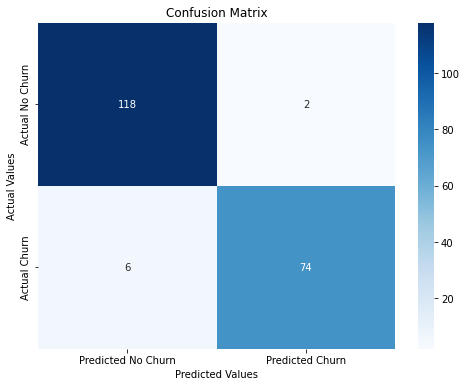

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

#### Confusion Matrix Interpretation

The Confusion Matrix provides a more detailed understanding of our classification model’s performance. The columns represent the predicted classes, and the rows represent the actual classes.

* **True Negatives (TN):** The number of customers the model predicted would not churn and who actually did not churn. (Top-left corner)  
* **False Positives (FP):** The number of customers the model predicted would churn but who actually did not churn. (Top-right corner – Type I Error)  
* **False Negatives (FN):** The number of customers the model predicted would not churn but who actually did churn. (Bottom-left corner – Type II Error)  
* **True Positives (TP):** The number of customers the model predicted would churn and who actually did churn. (Bottom-right corner)

This matrix helps us see which types of errors the model makes more frequently. For example, a high number of False Negatives indicates that the model is missing some customers who will churn, while a high number of False Positives indicates that the model is incorrectly labeling some non-churning customers as churners.

In scenarios like churn prediction, we usually want to minimize False Negatives (i.e., avoid missing customers who will churn). This highlights the importance of the Recall metric.

### Result Interpretation and Feature Importance

In [14]:
# Get feature names from the training data
feature_names = X_train.columns

# Get coefficients from the trained model
coefficients = model.coef_[0]

# Create a DataFrame to store feature names and coefficients
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Compute the absolute value of coefficients to determine importance
feature_importance_df['abs_coefficient'] = feature_importance_df['coefficient'].abs()

# Sort features by absolute coefficient in descending order
feature_importance_df = feature_importance_df.sort_values(by='abs_coefficient', ascending=False)

# Display the top N most important features
top_n = 20
print(f"Top {top_n} features influencing churn:")
display(feature_importance_df.head(top_n))

# Interpret the results
print("\nInterpretation of the top features:")
for index, row in feature_importance_df.head(top_n).iterrows():
    feature = row['feature']
    coefficient = row['coefficient']
    if coefficient > 0:
        print(f"- {feature}: Coefficient = {coefficient:.4f}. This feature increases the likelihood of churn.")
    else:
        print(f"- {feature}: Coefficient = {coefficient:.4f}. This feature decreases the likelihood of churn.")

Top 20 features influencing churn:


,feature,coefficient,abs_coefficient
4,Recency,5.662030,5.662030
997,RFM_Segment_311.0,1.878925,1.878925
1014,RFM_Segment_No Orders,-0.777504,0.777504
1005,RFM_Segment_412.0,-0.705328,0.705328
998,RFM_Segment_312.0,0.601437,0.601437
541,city_New Jadehaven,0.510869,0.510869
939,city_West Lachlan,0.492707,0.492707
684,city_Port Ella,0.477903,0.477903
90,city_Caitlinview,0.469462,0.469462
451,city_Langfort,0.461127,0.461127



Interpretation of the top features:
- Recency: Coefficient = 5.6620. This feature increases the likelihood of churn.
- RFM_Segment_311.0: Coefficient = 1.8789. This feature increases the likelihood of churn.
- RFM_Segment_No Orders: Coefficient = -0.7775. This feature decreases the likelihood of churn.
- RFM_Segment_412.0: Coefficient = -0.7053. This feature decreases the likelihood of churn.
- RFM_Segment_312.0: Coefficient = 0.6014. This feature increases the likelihood of churn.
- city_New Jadehaven: Coefficient = 0.5109. This feature increases the likelihood of churn.
- city_West Lachlan: Coefficient = 0.4927. This feature increases the likelihood of churn.
- city_Port Ella: Coefficient = 0.4779. This feature increases the likelihood of churn.
- city_Caitlinview: Coefficient = 0.4695. This feature increases the likelihood of churn.
- city_Langfort: Coefficient = 0.4611. This feature increases the likelihood of churn.
- city_Ernserland: Coefficient = 0.4475. This feature increases 

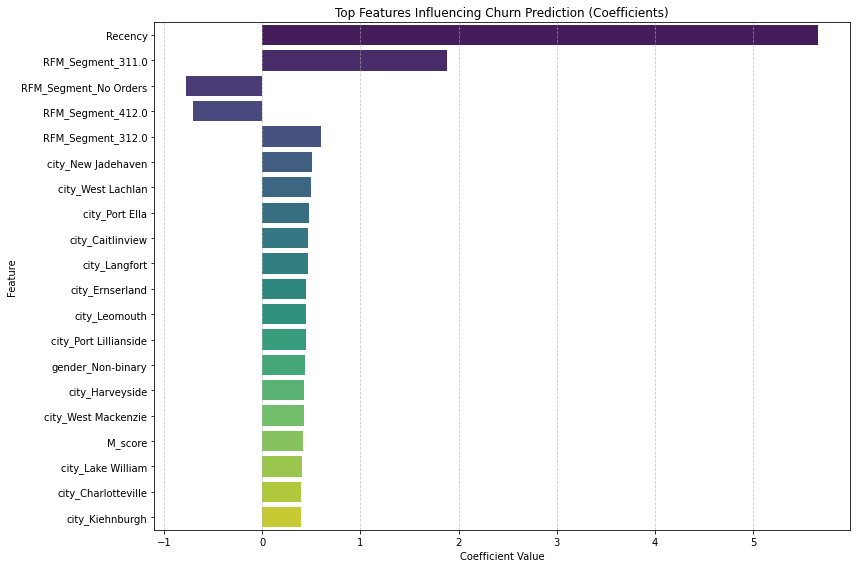

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top N features
top_n = 20
top_features = feature_importance_df.head(top_n)

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='coefficient', y='feature', data=top_features, palette='viridis')
plt.title('Top Features Influencing Churn Prediction (Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Final Strategies and Project Completion

Based on the analysis of the most important features influencing churn, potential strategies to reduce customer churn are as follows:

**Focus on Recency:**
- **Observation:** High 'Recency' (longer time since last order) strongly increases the likelihood of churn.
- **Strategy:** Implement re-engagement campaigns for customers with high recency. Offer personalized discounts, promotions, or new product reminders to encourage them to interact again.

**Analyze RFM Segments:**
- **Observation:** Certain RFM segments such as 311.0, 211.0, 312.0, 111.0, and 322.0 show increased churn risk, while segments like 'No Orders', 412.0, and 411.0 show lower churn risk.
- **Strategy:**
  - For high-risk segments (e.g., 311.0 – likely recent order but low frequency/monetary value), understand why engagement is low despite recent activity. This may involve surveys or analyzing purchase patterns.
  - Develop targeted retention programs aimed at increasing frequency or monetary value for high-risk segments.
  - The negative coefficient for 'No Orders' may seem counterintuitive; it indicates that customers who haven’t placed an order during the observed period may have lower churn risk compared to certain risky RFM segments with prior orders. Further investigation into the behavior of this group is needed.
  - Negative coefficients for 412.0 and 411.0 suggest that these customers (possibly occasional high-value buyers) are less likely to churn. Focus on maintaining engagement without excessive outreach.

**Consider Gender and Location Factors:**
- **Observation:** 'gender_Non-binary' and 'gender_Genderqueer' show increased churn risk. Certain states (Western Australia, Victoria, Queensland) and cities also appear among top positive contributors to churn, while 'state_Australian Capital Territory' has a negative coefficient.
- **Strategy:**
  - Investigate if there are specific product or service issues affecting customers in these gender categories or geographic areas. This may involve analyzing feedback or support requests.
  - Tailor marketing and communication strategies to be inclusive and relevant for different gender identities.
  - Analyze regional differences in behavior, preferences, or potential service delivery issues that could contribute to churn in specific states or cities.

**Monitor Monetary Score (M_score):**
- **Observation:** Higher 'M_score' (monetary score) increases churn likelihood. This is counterintuitive and may require further investigation into scoring methodology or whether high-spending customers have different expectations or experiences.
- **Strategy:** Understand why high-value customers churn. Are they targeted by competitors? Are there product quality or service issues affecting large orders? Implement special programs to retain high-value customers.

**General Strategies:**
- **Proactive Engagement:** Identify customers showing high recency or belonging to high-risk RFM segments and engage them proactively before churn occurs.
- **Collect Feedback:** Implement mechanisms to gather feedback, especially from customers showing reduced activity or belonging to high-risk segments, to understand their issues.
- **Personalization:** Use identified features to personalize offers, recommendations, and communications to make customers feel valued and understood.

The customer churn prediction project has been successfully completed.

## Summary

### Key Findings from Data Analysis

- All six datasets (`customers.csv`, `orders_with_churn_and_payment.csv`, `products_updated.csv`, `sales_updated.csv`, `customer_segment_data_rfm_df.csv`, and `customer_segment_data_kMeans.csv`) were successfully loaded and explored.
- Initial data exploration revealed missing values in the `payment` column of `orders_df`.
- Customer-level features, including total orders, total payment, RFM metrics (Recency, Frequency, Monetary, and corresponding scores), RFM segments, and KMeans clusters, were successfully engineered and consolidated into a single `merged_df` DataFrame.
- Missing numerical values in the merged DataFrame were filled with 0, and missing `RFM_Segment` values were filled with 'No Orders'.
- Irrelevant columns such as customer name, address, zip code, and country were removed from the merged DataFrame.
- Cohort analysis was successfully performed: each customer’s first order date was identified, and retention rates over time were calculated and visualized using a heatmap.
- The data was prepared for modeling by applying one-hot encoding to categorical variables and scaling numerical features using `StandardScaler`.
- The dataset was split into training (80%) and test (20%) sets.
- A Logistic Regression model was selected and trained on the prepared data.
- The model achieved promising evaluation metrics on the test set: Accuracy 0.9600, Precision 0.9737, Recall 0.9250, F1-Score 0.9487, and AUC-ROC 0.9542.
- Feature importance analysis showed that `Recency` was the most influential factor for predicting churn, followed by various RFM segments, specific cities, and gender categories.
- An unexpected finding was that higher `Monetary` scores and the 'No Orders' RFM segment had negative coefficients, suggesting a lower likelihood of churn; this requires further investigation into the data or scoring methodology.

### Insights and Next Steps

- Investigate the counterintuitive impact of `Monetary` scores and the 'No Orders' RFM segment on churn probability to ensure data integrity or understand underlying customer behavior patterns.
- Develop targeted churn-prevention strategies based on the key identified features, particularly focusing on customers with high Recency, those in high-risk RFM segments, and potentially customers in specific geographic locations or gender categories.